In [1]:
import itertools
import os
import shutil
from pathlib import Path
from typing import List

import autorootcwd
import click
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from natsort import natsorted
from PIL import Image
from tqdm import tqdm

In [4]:
WORKDIR_DIR = Path("workdir")
FIGURES_DIR = Path("figures")
DEFAULT_MODELS = ["Unet", "SwinUNETR", "CSNet", "FRUnet"]


def _get_workdir_path(sampling_method: str, loss: str, image_type: str, dataset: str, model: str) -> Path:
    """작업 디렉토리 경로 생성 로직 단일화"""
    dir_name = f"{sampling_method}-{loss}-{image_type}/{dataset}-{model}" if sampling_method else f"{dataset}-{model}"
    return WORKDIR_DIR / dir_name

Image 0.0 1.0 float32
Output 0 1 uint8
Target 0.0 1.0 float32
Image 0.0 1.0 float32
Output 0 1 uint8
Target 0.0 1.0 float32
Image 0.0 1.0 float32
Output 0 1 uint8
Target 0.0 1.0 float32
Image 0.0 1.0 float32
Output 0 1 uint8
Target 0.0 1.0 float32


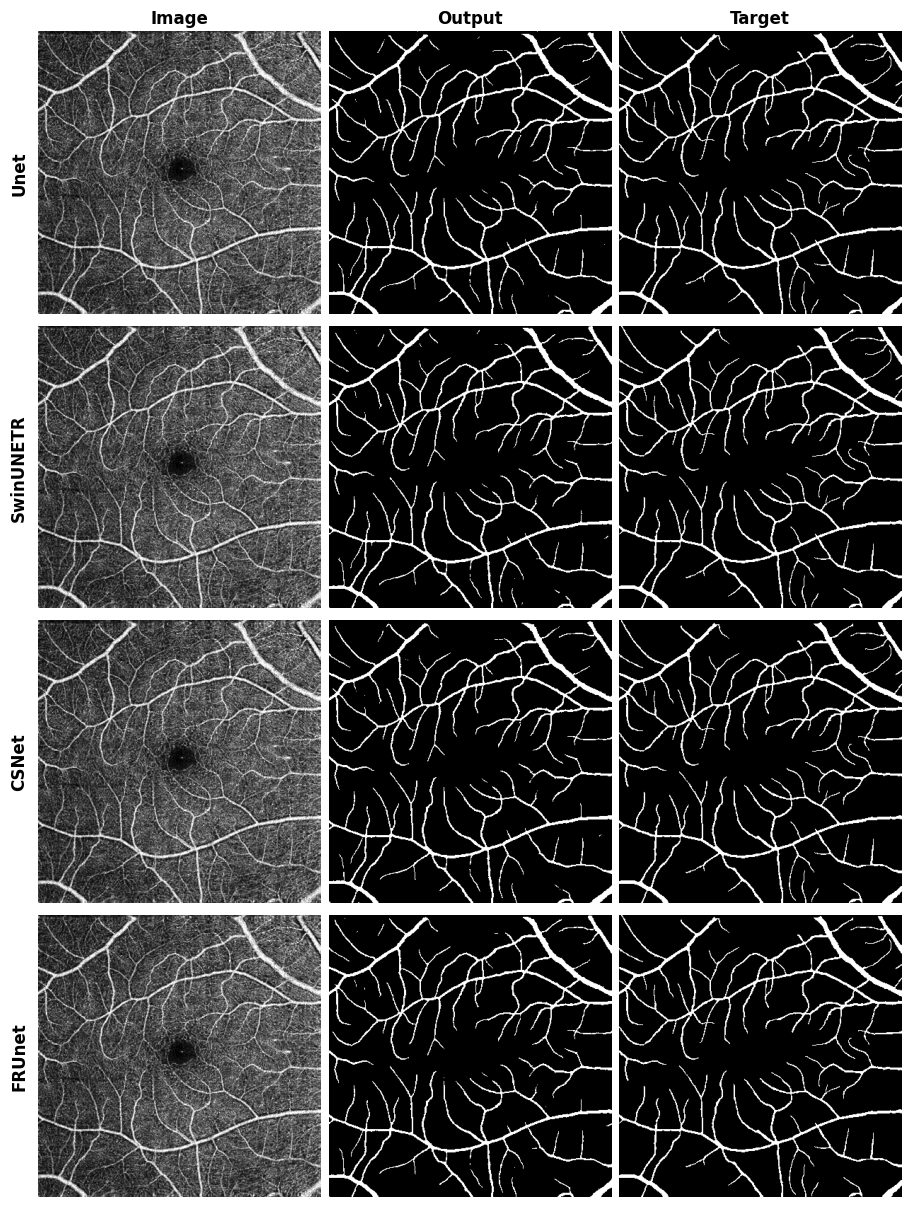

Image 0.0 1.0 float32
Output 0 1 uint8
Target 0.0 1.0 float32
Image 0.0 1.0 float32
Output 0 1 uint8
Target 0.0 1.0 float32
Image 0.0 1.0 float32
Output 0 1 uint8
Target 0.0 1.0 float32
Image 0.0 1.0 float32
Output 0 1 uint8
Target 0.0 1.0 float32


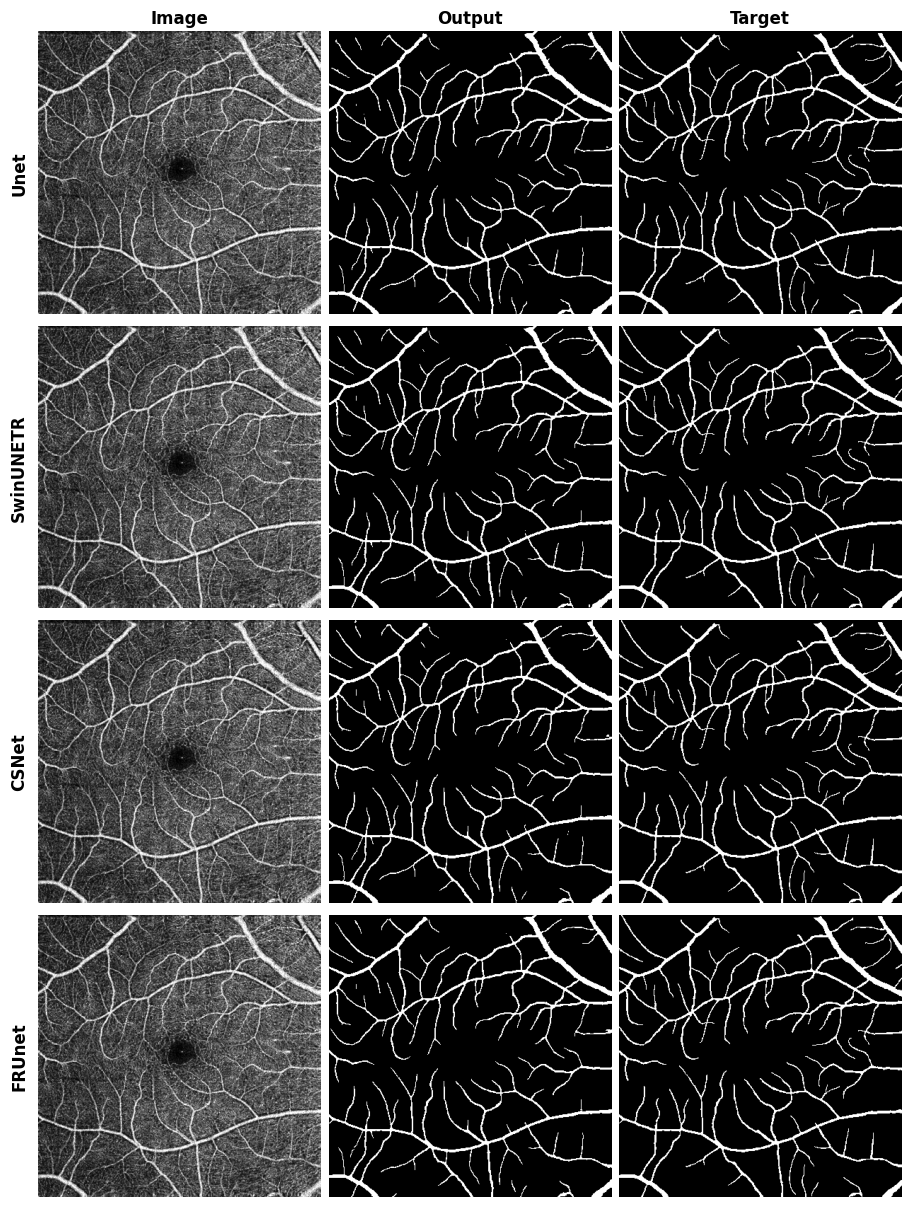

In [5]:
def plot_results(dataset: str, sampling_method: str = "", models: List[str] = DEFAULT_MODELS, index: int = 0):
    """Generate comparison plots."""
    model_images = {}

    loss = "mse"
    image_type = "concat"
    # 이미지 검색 로직 최적화
    for model in models:
        work_path = _get_workdir_path(sampling_method, loss, image_type, dataset, model)
        # 최신 결과 폴더 찾기
        res_dirs = sorted(work_path.glob("results-*"))
        if not res_dirs:
            print(f"No result directories found for {model} in {work_path}")
            continue

        latest_dir = res_dirs[-1]
        images = natsorted(list(latest_dir.glob("*image*")))
        targets = natsorted(list(latest_dir.glob("*target*")))
        outputs = natsorted(list(latest_dir.glob("*final_output*")))

        if not images  or not targets or not outputs:
            print(f"Missing files in {latest_dir}")
            continue

        imgs = {
            "Image": images[index],
            "Output": outputs[index],
            "Target": targets[index]
        }

        if all(p.exists() for p in imgs.values()):
            model_images[model] = imgs

    if not model_images:
        print(f"No images found for plotting {sampling_method}-{loss}-{image_type}-{dataset}")
        return

    n_models = len(model_images)
    fig, axes = plt.subplots(n_models, 3, figsize=(9, 3 * n_models), constrained_layout=True)
    if n_models == 1:
        axes = axes[None, :]

    for idx, (model, files) in enumerate(model_images.items()):
        for col, (title, path) in enumerate(files.items()):
            ax = axes[idx, col] if n_models > 1 else axes[0, col]
            if path.suffix == ".npy":
                data = np.load(path)
                data = np.squeeze(data)
                print(title, data.min(), data.max(), data.dtype)
                img = Image.fromarray((data * 255).astype(np.uint8))
            else:
                img = Image.open(path).convert("L")  # 흑백 변환 통일
            ax.imshow(img, cmap='gray')
            ax.axis('off')

            if idx == 0:
                ax.set_title(title, fontsize=12, fontweight='bold')
            if col == 0:
                ax.text(-0.1, 0.5, model, transform=ax.transAxes,
                        rotation=90, va='center', fontsize=12, fontweight='bold')

    plt.show()

    plt.close()
%matplotlib inline
# datasets = ["DRIVE", "OCTA500_3M", "OCTA500_6M"]
datasets = ["OCTA500_6M"]
models = DEFAULT_MODELS
# sampling_methods = ["gaussian", "bernoulli", "poisson"]
sampling_methods = ["binomial", "poisson"]

configs = list(itertools.product(sampling_methods, datasets, models))
unique_ds_sm = set((ds, sm) for sm, ds, _ in configs)
for ds, sm in unique_ds_sm:
    plot_results(ds, sm, models)

In [ ]:
from natsort import natsorted


def plot_results_separately(dataset: str, sampling_method: str = "", models: List[str] = DEFAULT_MODELS, index: int = 0):
    """Generate comparison plots."""
    model_images = {}

    # 이미지 검색 로직 최적화
    for model in models:
        work_path = _get_workdir_path(dataset, model, sampling_method)
        # 최신 결과 폴더 찾기
        res_dirs = sorted(work_path.glob("results-*"))
        if not res_dirs:
            continue

        latest_dir = res_dirs[-1]
        images = natsorted(list(latest_dir.glob("*image*")))
        inputs = natsorted(list(latest_dir.glob("*input*")))
        targets = natsorted(list(latest_dir.glob("*target*")))
        outputs = natsorted(list(latest_dir.glob("*final_output*")))

        lengths = [len(images), len(inputs), len(targets), len(outputs)]
        if min(lengths) == 0:
            print(f"Missing files in {latest_dir}")
            continue

        max_idx = min(lengths) - 1
        safe_idx = min(index, max_idx)

        # 샘플 기준 이미지 경로 매핑
        imgs = {
            "Image": images[safe_idx],
            "Input": inputs[safe_idx],
            "Output": outputs[safe_idx],
            "Target": targets[safe_idx]
        }

        if all(p.exists() for p in imgs.values()):
            model_images[model] = imgs

    if not model_images:
        print(f"No images found for plotting {sampling_method}-{dataset}")
        return

    os.makedirs(FIGURES_DIR / "separated", exist_ok=True)

    for idx, (model, files) in enumerate(model_images.items()):
        for col, (title, path) in enumerate(files.items()):
            plt.figure(figsize=(3, 3), frameon=False)
            print(model, title)

            if path.suffix == ".npy":
                data = np.load(path)
                data = np.asarray(data, dtype=np.float32)
                data = np.squeeze(data)
                if data.ndim > 2:
                    data = data[..., 0]
                dmin = float(data.min())
                dmax = float(data.max())
                rng = dmax - dmin
                if rng > 0:
                    data = (data - dmin) / rng
                else:
                    data = np.zeros_like(data)
                plt.imshow(data, cmap='gray', vmin=0.0, vmax=1.0)
                plt.axis('off')
                plt.show()
                plt.imsave(FIGURES_DIR / "separated" / f"{dataset}_{model}_{title}.png", data, cmap='gray', vmin=0.0, vmax=1.0)
            else:
                img = Image.open(path).convert("L")
                plt.imshow(img, cmap='gray')
                plt.axis('off')
                plt.show()
                plt.imsave(FIGURES_DIR / "separated" / f"{dataset}_{model}_{title}.png", np.array(img), cmap='gray')

    plt.close()

In [ ]:
#  plot image, input, output, target separtely for frunet model
for ds in datasets:
    plot_results_separately(ds, "poisson_flow", ["FRUnet"], index=0)

## Metrics

## Comparison of several models

In [10]:
import autorootcwd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from src.utils.evaluate import calculate_metrics

indexs = [24, 96]
# epochs = [50_000, 100_000]
epochs = [500_000]

images = []
targets = []
outputs = []
binomial_outputs = []
for epoch in epochs:
    for index in indexs:
        images.append(f"workdir/poisson-mse-concat/OCTA500_6M-FRUnet/results-{epoch:06d}/{index}_image.npy")
        targets.append(f"workdir/poisson-mse-concat/OCTA500_6M-FRUnet/results-{epoch:06d}/{index}_target.npy")
        outputs.append(f"workdir/poisson-mse-concat/OCTA500_6M-FRUnet/results-{epoch:06d}/{index}_final_output.npy")
        binomial_outputs.append(f"workdir/binomial-mse-concat/OCTA500_6M-FRUnet/results-{epoch:06d}/{index}_final_output.npy")

(400, 400) (400, 400) (400, 400) (400, 400)
0.0 1.0 [0. 1.]
0 1 [0 1]
0.0 1.0 [0. 1.]
(400, 400) (400, 400) (400, 400) (400, 400)


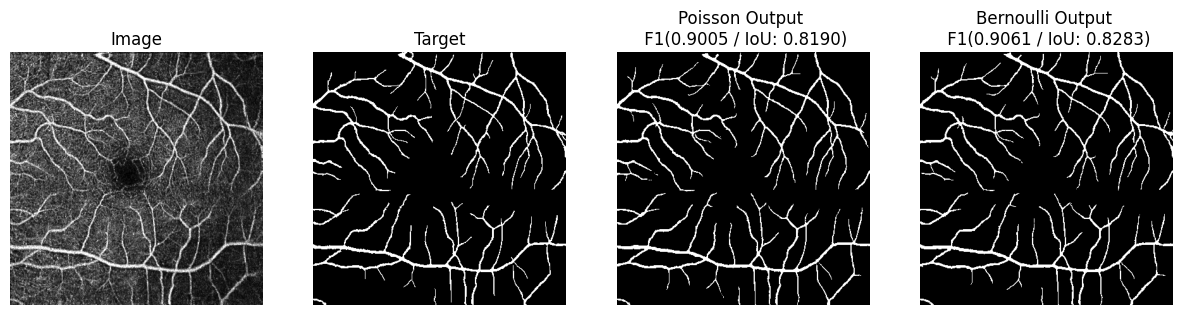

Input Metrics:
f1: 0.9061	| iou: 0.8283	| precision: 0.8791	| recall: 0.9348	| boundary_ap: 0.9307	| boundary_acc: 0.9857	| hd95: 1.0000	| betti_0_error: 12.0000	| betti_1_error: 1.0000	| 
f1: 0.9005	| iou: 0.8190	| precision: 0.8693	| recall: 0.9341	| boundary_ap: 0.9266	| boundary_acc: 0.9818	| hd95: 1.0000	| betti_0_error: 14.0000	| betti_1_error: 0.0000	| 
(400, 400) (400, 400) (400, 400) (400, 400)
0.0 1.0 [0. 1.]
0 1 [0 1]
0.0 1.0 [0. 1.]
(400, 400) (400, 400) (400, 400) (400, 400)


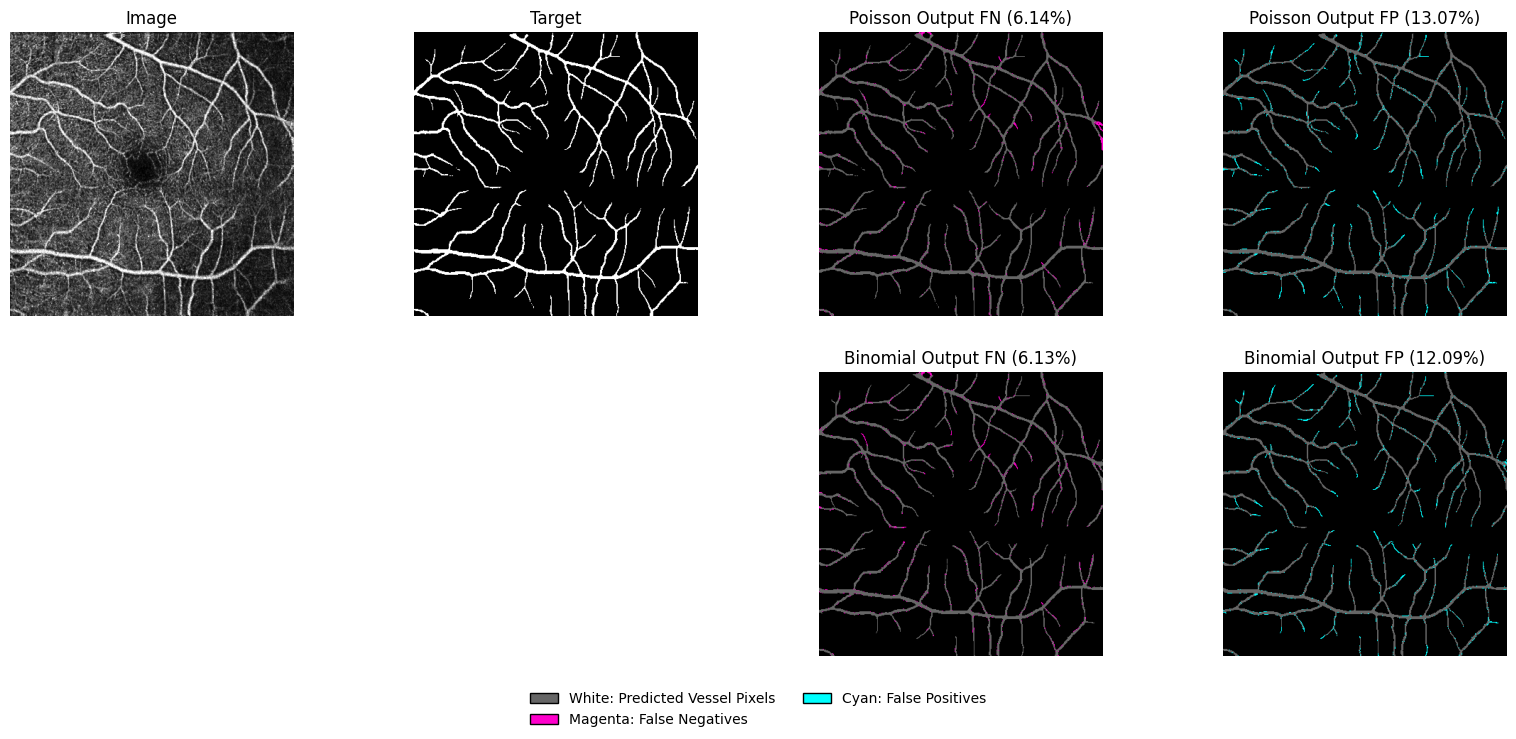

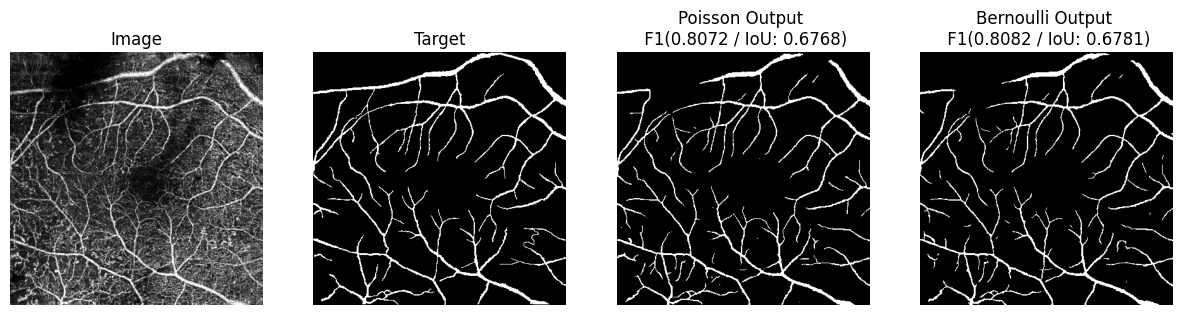

Input Metrics:
f1: 0.8082	| iou: 0.6781	| precision: 0.8492	| recall: 0.7709	| boundary_ap: 0.8813	| boundary_acc: 0.9014	| hd95: 3.6056	| betti_0_error: 48.0000	| betti_1_error: 0.0000	| 
f1: 0.8072	| iou: 0.6768	| precision: 0.8296	| recall: 0.7861	| boundary_ap: 0.8656	| boundary_acc: 0.9081	| hd95: 4.1231	| betti_0_error: 79.0000	| betti_1_error: 1.0000	| 


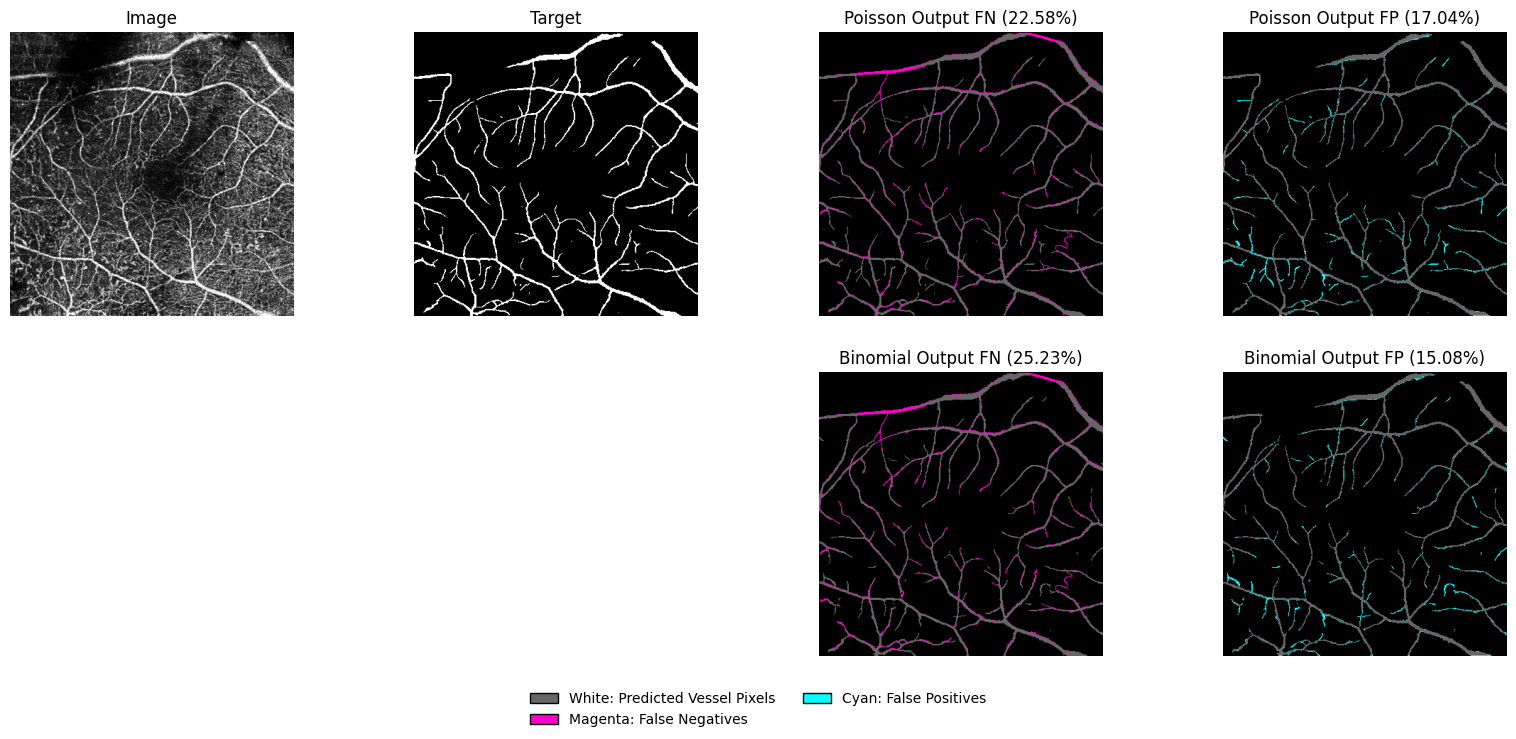

In [12]:
%matplotlib inline
from matplotlib.patches import Patch

# Process each output array separately
for idx in range(len(outputs)):
    image_arr = np.load(images[idx])[0]
    target_arr = np.load(targets[idx])[0]
    output_arr = np.load(outputs[idx])[..., 0]
    binomial_output_arr = np.load(binomial_outputs[idx])[..., 0]
    print(image_arr.shape, target_arr.shape,output_arr.shape, binomial_output_arr.shape)

    target_arr = (target_arr - target_arr.min()) / (target_arr.max() - target_arr.min())
    output_arr = (output_arr - output_arr.min()) / (output_arr.max() - output_arr.min())
    output_arr = (output_arr >= 0.5).astype(np.float32)

    print(target_arr.min(), target_arr.max(), np.unique(target_arr))
    print(binomial_output_arr.min(), binomial_output_arr.max(), np.unique(binomial_output_arr))
    print(output_arr.min(), output_arr.max(), np.unique(output_arr))
    binomial_output_metrics = calculate_metrics(pred=binomial_output_arr, label=target_arr)
    output_metrics = calculate_metrics(pred=output_arr, label=target_arr)
    print(target_arr.shape, binomial_output_arr.shape, output_arr.shape, image_arr.shape)

    target_mask = target_arr > 0.5
    output_mask = output_arr > 0.5
    binomial_output_mask = binomial_output_arr > 0.5
    # Error masks
    output_fp = np.logical_and(~target_mask, output_mask)
    output_fn = np.logical_and(target_mask, ~output_mask)
    binomial_output_fp = np.logical_and(~target_mask, binomial_output_mask)
    binomial_output_fn = np.logical_and(target_mask, ~binomial_output_mask)

    mispredicted_tp = np.logical_and(target_mask, ~output_mask)
    mispredicted_tn = np.logical_and(target_mask, output_mask)

    
    # Build RGB canvases with fluorescent colors
    output_fn_canvas = np.zeros((*output_arr.shape, 3), dtype=np.float32)
    output_fp_canvas = np.zeros((*output_arr.shape, 3), dtype=np.float32)
    binomial_output_fn_canvas = np.zeros((*binomial_output_arr.shape, 3), dtype=np.float32)
    binomial_output_fp_canvas = np.zeros((*binomial_output_arr.shape, 3), dtype=np.float32)

    output_fn_canvas[output_mask] = [0.4,0.4,0.4]
    output_fp_canvas[output_mask] = [0.4,0.4,0.4]
    binomial_output_fn_canvas[binomial_output_arr > 0] = [0.4,0.4,0.4]
    binomial_output_fp_canvas[binomial_output_arr > 0] = [0.4,0.4,0.4]

    neon_magenta = np.array([1.0, 0.0, 0.8], dtype=np.float32)
    neon_cyan = np.array([0.0, 1.0, 1.0], dtype=np.float32)

    output_fn_canvas[output_fn] = neon_magenta
    output_fp_canvas[output_fp] = neon_cyan
    binomial_output_fn_canvas[binomial_output_fn] = neon_magenta
    binomial_output_fp_canvas[binomial_output_fp] = neon_cyan

    fig = plt.figure(figsize=(15, 5))
    plt.subplot(1,4, 1)
    plt.title("Image")
    plt.imshow(image_arr, cmap='gray')
    plt.axis('off')
    plt.subplot(1,4, 2)
    plt.title("Target")
    plt.imshow(target_arr, cmap='gray')
    plt.axis('off')

    plt.subplot(1,4, 3)
    plt.title(f"Poisson Output \n F1({output_metrics['f1']:.4f} / IoU: {output_metrics['iou']:.4f})")
    plt.imshow(output_arr, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1,4, 4)
    plt.title(f"Bernoulli Output \n F1({binomial_output_metrics['f1']:.4f} / IoU: {binomial_output_metrics['iou']:.4f})")
    plt.imshow(binomial_output_arr, cmap='gray')
    plt.axis('off')
       
    plt.show()
    
    fig = plt.figure(figsize=(20, 8))
    plt.subplot(2,4, 1)
    plt.title("Image")
    plt.imshow(image_arr, cmap='gray')
    plt.axis('off')
    plt.subplot(2,4, 2)
    plt.title(f"Target")
    plt.imshow(output_arr,cmap='gray')
    plt.axis('off')
    plt.subplot(2,4, 3)
    plt.title(f"Poisson Output FN ({np.sum(output_fn) / np.sum(output_mask):.2%})")
    plt.imshow(output_fn_canvas)
    plt.axis('off')
    plt.subplot(2,4, 4)
    plt.title(f"Poisson Output FP ({np.sum(output_fp) / np.sum(output_mask):.2%})")
    plt.imshow(output_fp_canvas)
    plt.axis('off')
    plt.subplot(2,4, 7)
    plt.title(f"Binomial Output FN ({np.sum(binomial_output_fn) / np.sum(binomial_output_mask):.2%})")
    plt.imshow(binomial_output_fn_canvas)
    plt.axis('off')
    plt.subplot(2,4, 8)
    plt.title(f"Binomial Output FP ({np.sum(binomial_output_fp) / np.sum(binomial_output_mask):.2%})")
    plt.imshow(binomial_output_fp_canvas)
    plt.axis('off')
    
    fig.subplots_adjust(bottom=0.1)
    legend_handles = [
        Patch(facecolor=[0.4,0.4,0.4], edgecolor='black', label='White: Predicted Vessel Pixels'),
        Patch(facecolor=neon_magenta, edgecolor='black', label='Magenta: False Negatives'),
        Patch(facecolor=neon_cyan, edgecolor='black', label='Cyan: False Positives'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False)

    print("Input Metrics:")
    metrics = calculate_metrics(pred=binomial_output_arr, label=target_arr)
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}", end='\t| ')
    print()
    metrics = calculate_metrics(pred=output_arr, label=target_arr)
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}", end='\t| ')
    print()
